In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

#IMPORT THE LIBRARIES
import pandas as pd
import numpy as np

import os
import sys

import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

# to play the audio files
import IPython.display as ipd
from IPython.display import Audio
import keras
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.layers import LSTM,BatchNormalization , GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD



import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
import tensorflow as tf
print ("Done")

Mounted at /content/drive
Done


In [ ]:
import os
import pandas as pd

# Define dataset path
dataset_path = "/content/drive/MyDrive/dataset/TESS_Merged/"

# Selected classes
selected_classes = ["Anxiety", "Depression", "Normal"]

file_emotion = []
file_path = []

# Loop through selected directories only
for dir in selected_classes:
    dir_path = os.path.join(dataset_path, dir)

    # Check if directory exists
    if not os.path.exists(dir_path):
        print(f"❌ Warning: {dir} folder not found in {dataset_path}")
        continue

    # Process files in the directory
    for file in os.listdir(dir_path):
        file_path.append(os.path.join(dir_path, file))
        file_emotion.append(dir)  # Assign class name directly

# Create DataFrame
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
path_df = pd.DataFrame(file_path, columns=['Path'])

Tess_df = pd.concat([emotion_df, path_df], axis=1)
# Display class distribution
print(Tess_df.Emotions.value_counts())

Emotions
Normal        1600
Depression     800
Anxiety        400
Name: count, dtype: int64


In [ ]:
Tess_df.head()

,Emotions,Path
0,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
1,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
2,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
3,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
4,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...


In [ ]:
# creating Dataframe using all the 4 dataframes we created so far.
Tess_df.to_csv("/content/drive/MyDrive/dataset/TESS_dataset.csv",index=False)
Tess_df.head()

,Emotions,Path
0,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
1,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
2,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
3,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
4,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...


In [ ]:
print(Tess_df.Emotions.value_counts())

Emotions
Normal        1600
Depression     800
Anxiety        400
Name: count, dtype: int64


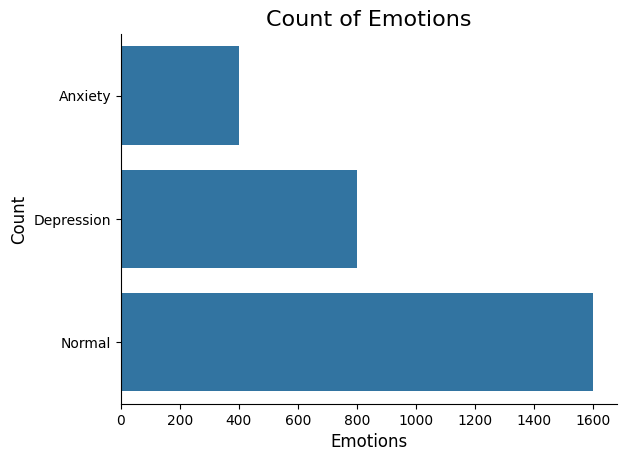

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.title('Count of Emotions', size=16)
sns.countplot(Tess_df.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

In [ ]:
import pandas as pd

# Find the minimum count of samples per class
min_count = Tess_df['Emotions'].value_counts().min()

# Perform undersampling
balanced_df = Tess_df.groupby('Emotions').apply(lambda x: x.sample(n=min_count, random_state=42)).reset_index(drop=True)

# Save balanced dataset
balanced_df.to_csv("/content/drive/MyDrive/dataset/TESS_balanced_dataset.csv", index=False)

# Display new class distribution
print(balanced_df['Emotions'].value_counts())

# Show first few rows
balanced_df.head()


Emotions
Anxiety       400
Depression    400
Normal        400
Name: count, dtype: int64


,Emotions,Path
0,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
1,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
2,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
3,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...
4,Anxiety,/content/drive/MyDrive/dataset/TESS_Merged/Anx...


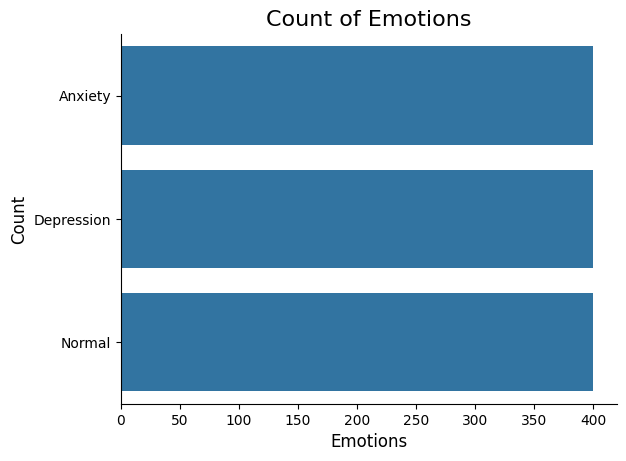

In [ ]:
plt.title('Count of Emotions', size=16)
sns.countplot(balanced_df.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

In [ ]:
# Load the balanced dataset
balanced_dataset_path = "/content/drive/MyDrive/dataset/TESS_balanced_dataset.csv"
balanced_df = pd.read_csv(balanced_dataset_path)

# Get the first file path
first_file_path = balanced_df["Path"].iloc[0]  # First file from balanced dataset

# Load the audio file
data, sr = librosa.load(first_file_path, sr=None)  # sr=None keeps original sample rate

# Print sample rate
print("Sample Rate:", sr)

Sample Rate: 24414


In [ ]:
ipd.Audio(data,rate=sr)

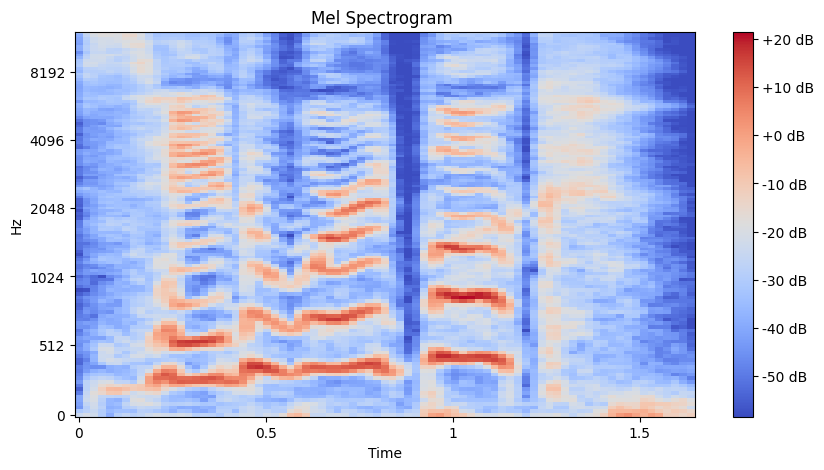

In [ ]:
# CREATE LOG MEL SPECTROGRAM
plt.figure(figsize=(10, 5))
spectrogram = librosa.feature.melspectrogram(y=data, sr=sr, n_mels=128,fmax=8000)
log_spectrogram = librosa.power_to_db(spectrogram)
librosa.display.specshow(log_spectrogram, y_axis='mel', sr=sr, x_axis='time');
plt.title('Mel Spectrogram ')
plt.colorbar(format='%+2.0f dB')

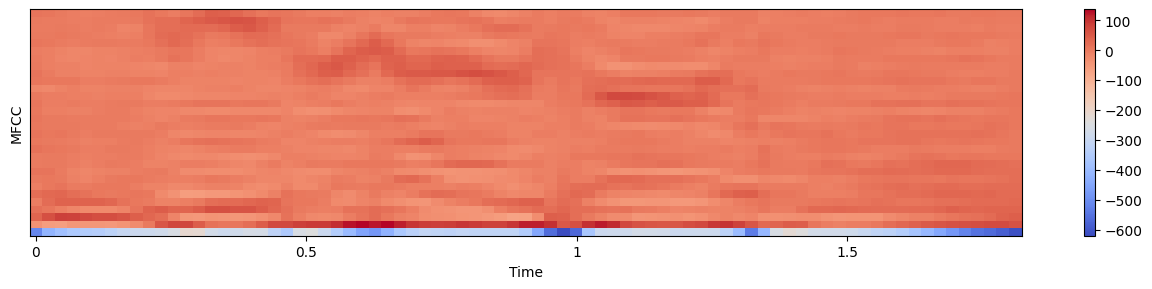

In [ ]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=30)


# MFCC
plt.figure(figsize=(16, 10))
plt.subplot(3,1,1)
librosa.display.specshow(mfcc, x_axis='time')
plt.ylabel('MFCC')
plt.colorbar()

ipd.Audio(data,rate=sr)

In [ ]:
# NOISE
def noise(data):
    noise_amp = 0.035*np.random.uniform()*np.amax(data)
    data = data + noise_amp*np.random.normal(size=data.shape[0])
    return data

# STRETCH
def stretch(data, rate=0.8):
    if len(data.shape) > 1:  # Check if stereo
        data = librosa.to_mono(data)  # Convert to mono

    data = np.ascontiguousarray(data)  # Ensure it's a NumPy array
    return librosa.effects.time_stretch(y=data, rate=rate)

# SHIFT
def shift(data):
    shift_range = int(np.random.uniform(low=-5, high = 5)*1000)
    return np.roll(data, shift_range)

# PITCH SHIFT FUNCTION
def pitch(data, sampling_rate, pitch_factor=0.7):
    if len(data.shape) > 1:  # Convert stereo to mono if needed
        data = librosa.to_mono(data)

    data = np.ascontiguousarray(data)  # Ensure it's a NumPy array
    return librosa.effects.pitch_shift(y=data, sr=sampling_rate, n_steps=pitch_factor)

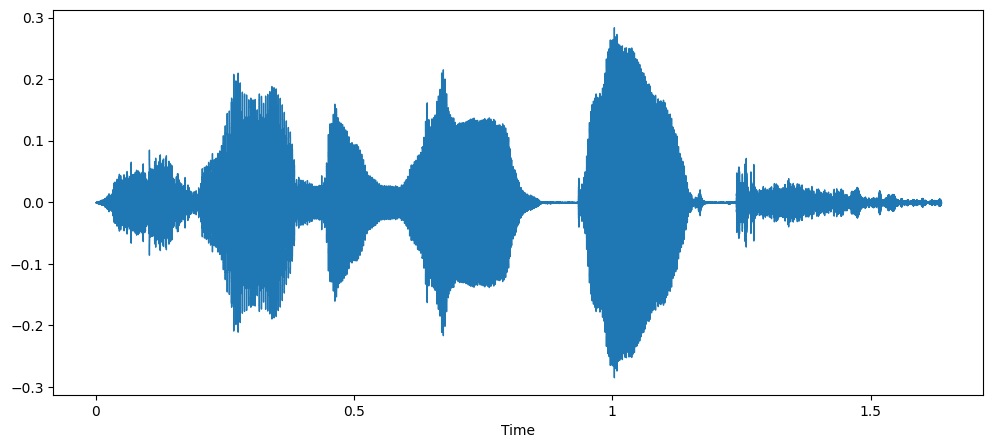

In [ ]:
# NORMAL AUDIO
import librosa.display
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=data, sr=sr)
ipd.Audio(data,rate=sr)

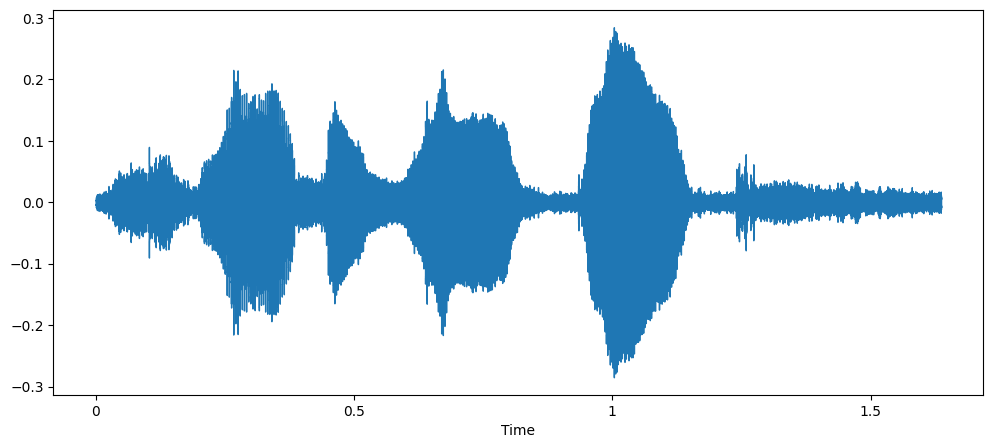

In [ ]:
# AUDIO WITH NOISE
x = noise(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

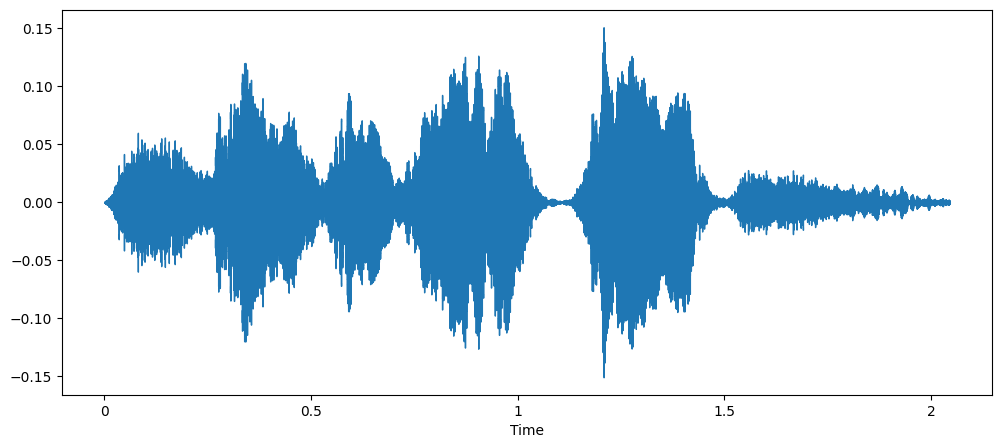

In [ ]:
# STRETCHED AUDIO
x = stretch(data)
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

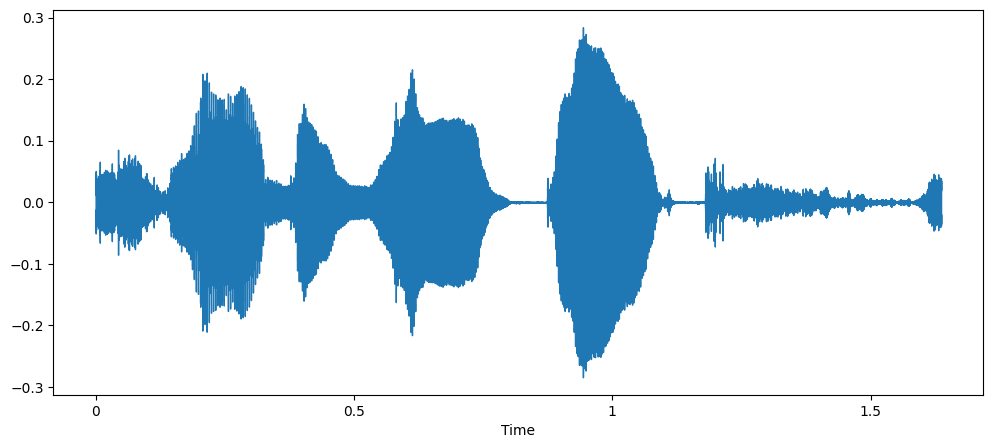

In [ ]:
# SHIFTED AUDIO
x = shift(data)
plt.figure(figsize=(12,5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

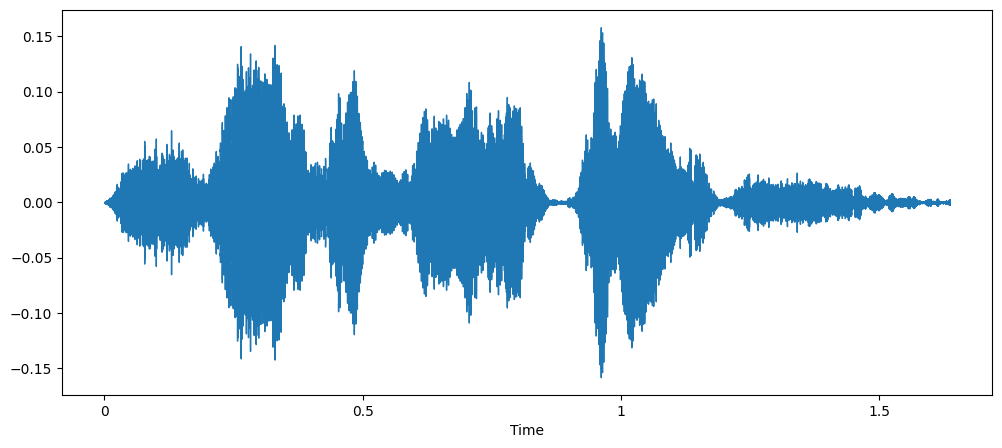

In [ ]:
# AUDIO WITH PITCH
x = pitch(data, sr)
plt.figure(figsize=(12, 5))
librosa.display.waveshow(y=x, sr=sr)
ipd.Audio(x, rate=sr)

In [ ]:
def zcr(data,frame_length,hop_length):
    zcr=librosa.feature.zero_crossing_rate(data,frame_length=frame_length,hop_length=hop_length)
    return np.squeeze(zcr)
def rmse(data, frame_length=2048, hop_length=512):
    rmse = librosa.feature.rms(y=data, frame_length=frame_length, hop_length=hop_length)
    return np.squeeze(rmse)
def mfcc(data, sr, frame_length=2048, hop_length=512, flatten: bool = True):
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=32)  # Ensure y= is used
    return np.squeeze(mfcc.T) if not flatten else np.ravel(mfcc.T)

def extract_features(data,sr=22050,frame_length=2048,hop_length=512):
    result=np.array([])

    result=np.hstack((result,
                      zcr(data,frame_length,hop_length),
                      rmse(data,frame_length,hop_length),
                      mfcc(data,sr,frame_length,hop_length)
                     ))
    return result

def get_features(path,duration=2.5, offset=0.6):
    data,sr=librosa.load(path,duration=duration,offset=offset)
    aud=extract_features(data)
    audio=np.array(aud)

    noised_audio=noise(data)
    aud2=extract_features(noised_audio)
    audio=np.vstack((audio,aud2))

    pitched_audio=pitch(data,sr)
    aud3=extract_features(pitched_audio)
    audio=np.vstack((audio,aud3))

    pitched_audio1=pitch(data,sr)
    pitched_noised_audio=noise(pitched_audio1)
    aud4=extract_features(pitched_noised_audio)
    audio=np.vstack((audio,aud4))

    return audio

In [ ]:
import timeit
from tqdm import tqdm
start = timeit.default_timer()
X,Y=[],[]
for path,emotion,index in tqdm (zip(balanced_df.Path,balanced_df.Emotions,range(balanced_df.Path.shape[0]))):
    features=get_features(path)
    if index%100==0:
        print(f'{index} audio has been processed')
    for i in features:
        X.append(i)
        Y.append(emotion)
print('Done')
stop = timeit.default_timer()

print('Time: ', stop - start)

0it [00:00, ?it/s]

0 audio has been processed


101it [00:46,  2.06it/s]

100 audio has been processed


201it [01:30,  2.56it/s]

...

1000 audio has been processed


1101it [08:40,  2.18it/s]

1100 audio has been processed


1200it [09:27,  2.12it/s]

Done
Time:  567.1019752999999


In [ ]:
len(X), len(Y), Tess_df.Path.shape

(4800, 4800, (2800,))

In [ ]:
Emotions = pd.DataFrame(X)
Emotions['Emotions'] = Y
Emotions.to_csv('/content/drive/MyDrive/dataset/emotion.csv', index=False)
Emotions.head()

,0,1,2,3,4,5,6,7,8,9,...,3493,3494,3495,3496,3497,3498,3499,3500,3501,Emotions
0,0.022949,0.038574,0.066895,0.084473,0.099121,0.112305,0.107910,0.098145,0.074707,0.052734,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety
1,0.029785,0.045410,0.074707,0.089355,0.100098,0.113770,0.108887,0.100098,0.083496,0.084961,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety
2,0.022949,0.038574,0.061523,0.077148,0.086914,0.083984,0.081055,0.074219,0.081055,0.085938,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety
3,0.028809,0.044922,0.069336,0.083984,0.088867,0.087891,0.086914,0.083008,0.100586,0.157227,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety
4,0.017090,0.023438,0.035645,0.039062,0.047363,0.057129,0.072754,0.087402,0.092773,0.094238,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety


In [ ]:
Emotions = pd.read_csv('/content/drive/MyDrive/dataset/emotion.csv')
Emotions.head()

,0,1,2,3,4,5,6,7,8,9,...,3493,3494,3495,3496,3497,3498,3499,3500,3501,Emotions
0,0.022949,0.038574,0.066895,0.084473,0.099121,0.112305,0.107910,0.098145,0.074707,0.052734,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety
1,0.029785,0.045410,0.074707,0.089355,0.100098,0.113770,0.108887,0.100098,0.083496,0.084961,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety
2,0.022949,0.038574,0.061523,0.077148,0.086914,0.083984,0.081055,0.074219,0.081055,0.085938,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety
3,0.028809,0.044922,0.069336,0.083984,0.088867,0.087891,0.086914,0.083008,0.100586,0.157227,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety
4,0.017090,0.023438,0.035645,0.039062,0.047363,0.057129,0.072754,0.087402,0.092773,0.094238,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Anxiety


In [ ]:
#taking all rows and all cols without last col for X which include features
#taking last col for Y, which include the emotions


X = Emotions.iloc[: ,:-1].values
Y = Emotions['Emotions'].values

In [ ]:
# As this is a multiclass classification problem onehotencoding our Y
from sklearn.preprocessing import StandardScaler, OneHotEncoder
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()

In [ ]:
print(Y.shape)
X.shape

(4800, 3)


(4800, 3502)

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=42,test_size=0.2, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((3840, 3502), (3840, 3), (960, 3502), (960, 3))

In [ ]:
# Check if any NaN values exist
print("NaN in X_train:", np.isnan(x_train).sum())
print("NaN in Y_train:", np.isnan(y_train).sum())
print("NaN in X_test:", np.isnan(x_test).sum())
print("NaN in Y_ttest:", np.isnan(y_test).sum())



NaN in X_train: 5402328
NaN in Y_train: 0
NaN in X_test: 1377680
NaN in Y_ttest: 0


In [ ]:
# If NaNs exist, replace them with 0
x_train = np.nan_to_num(x_train)
y_train = np.nan_to_num(y_train)
x_test = np.nan_to_num(x_test)
y_test = np.nan_to_num(y_test)

In [ ]:
# Check if any NaN values exist
print("NaN in X_train:", np.isnan(x_train).sum())
print("NaN in Y_train:", np.isnan(y_train).sum())
print("NaN in X_test:", np.isnan(x_test).sum())
print("NaN in Y_ttest:", np.isnan(y_test).sum())



NaN in X_train: 0
NaN in Y_train: 0
NaN in X_test: 0
NaN in Y_ttest: 0


In [ ]:
#reshape
X_train = x_train.reshape(x_train.shape[0] , x_train.shape[1] , 1)
X_test = x_test.reshape(x_test.shape[0] , x_test.shape[1] , 1)

In [ ]:
# scaling our data with sklearn's Standard scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((3840, 3502), (3840, 3), (960, 3502), (960, 3))

In [ ]:
import keras
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding
from keras.layers import LSTM,BatchNormalization , GRU

from tensorflow.keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import SGD
from keras.callbacks import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau


model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/best_model1_weights.h5', monitor='val_accuracy', save_best_only=True)
# Fix EarlyStopping: Use `val_accuracy` instead of `val_acc`
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=5, mode='max')

lr_reduction=ReduceLROnPlateau(monitor='val_acc',patience=3,verbose=1,factor=0.5,min_lr=0.00001)

In [ ]:
#Reshape for CNN_LSTM MODEL

x_traincnn =np.expand_dims(x_train, axis=2)
x_testcnn= np.expand_dims(x_test, axis=2)
x_traincnn.shape, y_train.shape, x_testcnn.shape, y_test.shape
#x_testcnn[0]

((3840, 3502, 1), (3840, 3), (960, 3502, 1), (960, 3))

In [ ]:
import tensorflow as tf
import tensorflow.keras.layers as L

# Fix: Import Dropout properly
from tensorflow.keras.layers import Dropout

# Define Model
model = tf.keras.Sequential([
    L.Input(shape=(X_train.shape[1], 1)),  # Fix: Use Input() instead of input_shape in Conv1D

    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),

    L.Conv1D(512, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.2),  # Corrected Dropout

    L.Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),

    L.Conv1D(256, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.2),  # Corrected Dropout

    L.Conv1D(128, kernel_size=3, strides=1, padding='same', activation='relu'),
    L.BatchNormalization(),
    L.MaxPool1D(pool_size=3, strides=2, padding='same'),
    Dropout(0.2),  # Corrected Dropout

    L.Flatten(),
    L.Dense(512, activation='relu'),
    L.BatchNormalization(),
    L.Dense(3, activation='softmax')
])

# Fix: Ensure metrics is a list
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display Model Summary
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 3502, 512)           │           3,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 3502, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 1751, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 1751, 512)           │       1,311,232 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 1751, 512)           │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 876, 512)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 876, 512)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 876, 256)            │         655,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 876, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 438, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 438, 256)            │         196,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 438, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 219, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 219, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_4 (Conv1D)                    │ (None, 219, 128)            │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 219, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_4 (MaxPooling1D)       │ (None, 110, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 110, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14080)               │              

 Total params: 9,484,931 (36.18 MB)

 Trainable params: 9,480,579 (36.17 MB)

 Non-trainable params: 4,352 (17.00 KB)

In [ ]:
history=model.fit(x_traincnn, y_train, epochs=50, validation_data=(x_testcnn, y_test), batch_size=64,callbacks=[early_stop,lr_reduction,model_checkpoint])


Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8496 - loss: 0.4368

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_acc` which is not available. Available metrics are: accuracy,loss,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


60/60 ━━━━━━━━━━━━━━━━━━━━ 44s 400ms/step - accuracy: 0.8508 - loss: 0.4332 - val_accuracy: 0.3323 - val_loss: 2.7466 - learning_rate: 0.0010
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 19s 319ms/step - accuracy: 0.9714 - loss: 0.0762 - val_accuracy: 0.4875 - val_loss: 1.8878 - learning_rate: 0.0010
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 323ms/step - accuracy: 0.9956 - loss: 0.0170 - val_accuracy: 0.3750 - val_loss: 9.9522 - learning_rate: 0.0010
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 20s 323ms/step - accuracy: 0.9876 - loss: 0.0382 - val_accuracy: 0.3917 - val_loss: 8.5032 - learning_rate: 0.0010
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 22s 344ms/step - accuracy: 0.9915 - loss: 0.0217 - val_accuracy: 0.6729 - val_loss: 1.5455 - learning_rate: 0.0010
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 334ms/step - accuracy: 0.9940 - loss: 0.0135 - val_accuracy: 0.6542 - val_loss: 1.7856 - learning_rate: 0.0010
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 21s 342ms/step - accuracy: 0.9926 - loss: 0.0194 - val_

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 1.0000 - loss: 3.9165e-04
Accuracy of our model on test data :  100.0 %


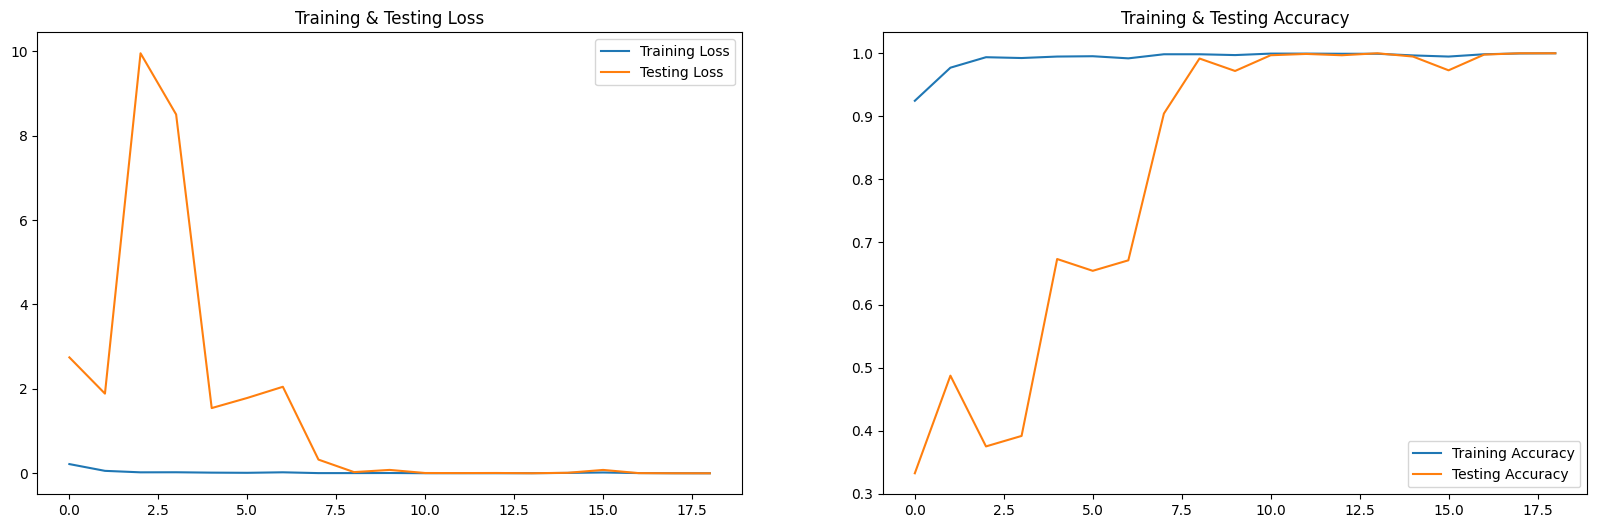

In [ ]:
# Evaluate model
print("Accuracy of our model on test data : ", model.evaluate(x_testcnn, y_test)[1] * 100, "%")

# Extract loss & accuracy from history
train_loss = history.history['loss']
test_loss = history.history['val_loss']
train_acc = history.history['accuracy']
test_acc = history.history['val_accuracy']

# Get actual number of recorded epochs
actual_epochs = len(train_loss)

# Plot Training & Testing Loss and Accuracy
fig, ax = plt.subplots(1, 2, figsize=(20, 6))

# Plot Loss
ax[0].plot(range(actual_epochs), train_loss, label='Training Loss')
ax[0].plot(range(actual_epochs), test_loss, label='Testing Loss')
ax[0].set_title('Training & Testing Loss')
ax[0].legend()

# Plot Accuracy
ax[1].plot(range(actual_epochs), train_acc, label='Training Accuracy')
ax[1].plot(range(actual_epochs), test_acc, label='Testing Accuracy')
ax[1].set_title('Training & Testing Accuracy')
ax[1].legend()

plt.show()


In [ ]:
# predicting on test data.
pred_test0 = model.predict(x_testcnn)
y_pred0 = encoder.inverse_transform(pred_test0)
y_test0 = encoder.inverse_transform(y_test)

# Check for random predictions
df0 = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df0['Predicted Labels'] = y_pred0.flatten()
df0['Actual Labels'] = y_test0.flatten()

df0.head(10)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step


,Predicted Labels,Actual Labels
0,Anxiety,Anxiety
1,Normal,Normal
2,Depression,Depression
3,Depression,Depression
4,Anxiety,Anxiety
5,Anxiety,Anxiety
6,Depression,Depression
7,Anxiety,Anxiety
8,Normal,Normal
9,Anxiety,Anxiety


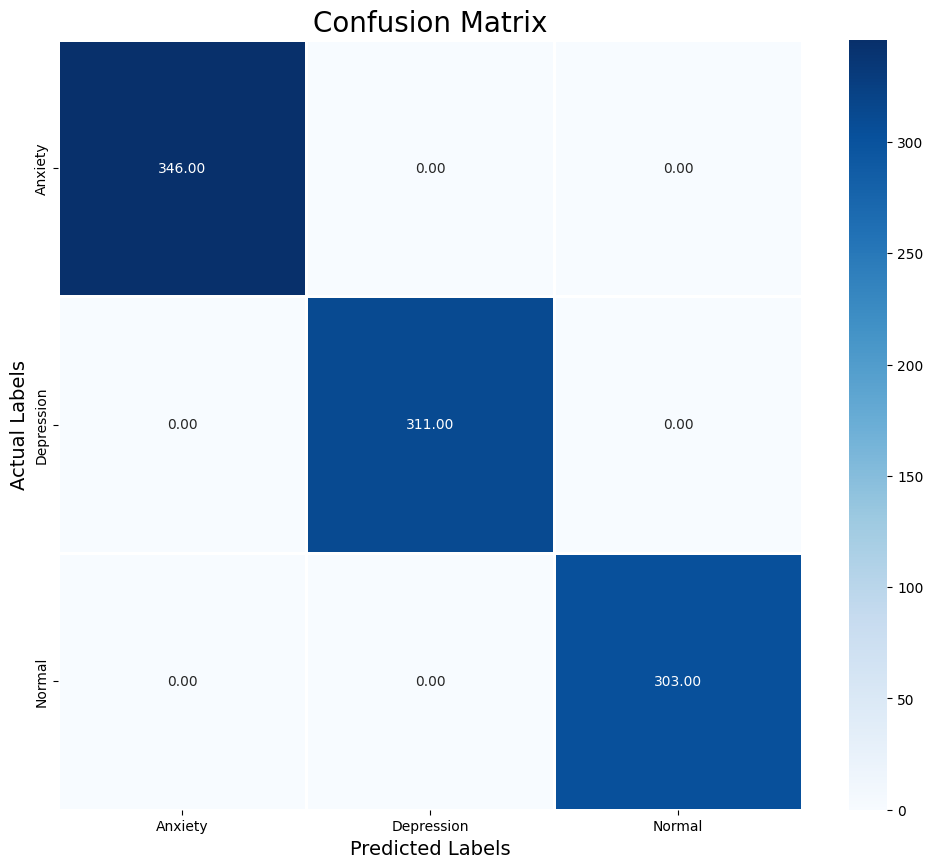

              precision    recall  f1-score   support

     Anxiety       1.00      1.00      1.00       346
  Depression       1.00      1.00      1.00       311
      Normal       1.00      1.00      1.00       303

    accuracy                           1.00       960
   macro avg       1.00      1.00      1.00       960
weighted avg       1.00      1.00      1.00       960



In [ ]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test0, y_pred0)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in encoder.categories_] , columns = [i for i in encoder.categories_])
#cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='.2f')
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()
print(classification_report(y_test0, y_pred0))

In [ ]:
from tensorflow.keras.models import Sequential, model_from_json # type: ignore
model_json = model.to_json()
with open("/content/drive/MyDrive/CNN_model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights("/content/drive/MyDrive/CNN_model.weights.h5")
print("Saved model to disk")

Saved model to disk


In [ ]:
import pickle

# Saving scaler
with open('/content/drive/MyDrive/scaler2.pickle', 'wb') as f:
    pickle.dump(scaler, f)


# Saving encoder
with open('/content/drive/MyDrive/encoder2.pickle', 'wb') as f:
    pickle.dump(encoder, f)



print("Done")

Done
